<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - Evaluation, Baselines, and Data Hygiene

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `3.4`.


## Common setup

The next cell contains only the base imports and low-level reusable helpers.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC

np.set_printoptions(precision=4, suppress=True)

I2 = np.eye(2, dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
CNOT01 = np.array([[1, 0, 0, 0],
                   [0, 1, 0, 0],
                   [0, 0, 0, 1],
                   [0, 0, 1, 0]], dtype=complex)
Z0 = np.kron(Z, I2)
PSI0 = np.array([1, 0, 0, 0], dtype=complex)


def print_metric_table(rows):
    header = f"{'split':<10} {'model':<24} {'accuracy':>10} {'F1':>10} {'ROC-AUC':>10}"
    print(header)
    print('-' * len(header))
    for row in rows:
        auc_str = f"{row['roc_auc']:.4f}" if row['roc_auc'] is not None else '   n/a   '
        print(f"{row['split']:<10} {row['model']:<24} {row['accuracy']:>10.4f} {row['f1']:>10.4f} {auc_str:>10}")


def metric_row(model_name, split_name, y_true, y_pred, y_score=None):
    row = {
        'model': model_name,
        'split': split_name,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred)),
        'roc_auc': None,
    }
    if y_score is not None:
        row['roc_auc'] = float(roc_auc_score(y_true, y_score))
    return row


def plot_confusion_matrices(confusions, title):
    model_names = list(confusions.keys())
    fig, axes = plt.subplots(1, len(model_names), figsize=(4.2 * len(model_names), 3.8))
    if len(model_names) == 1:
        axes = [axes]
    for ax, model_name in zip(axes, model_names):
        cm = confusions[model_name]
        ax.imshow(cm, cmap='Blues')
        ax.set_title(model_name)
        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black', fontsize=12)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def ry_matrix(theta):
    c = np.cos(theta / 2.0)
    s = np.sin(theta / 2.0)
    return np.array([[c, -s], [s, c]], dtype=complex)


def batch_quantum_scores(X, weights):
    U1 = np.kron(ry_matrix(weights[0]), ry_matrix(weights[1]))
    U2 = np.kron(ry_matrix(weights[2]), ry_matrix(weights[3]))
    U_ansatz = U2 @ CNOT01 @ U1
    scores = []
    for sample in X:
        U_feature = np.kron(ry_matrix(sample[0]), ry_matrix(sample[1]))
        psi = U_ansatz @ (U_feature @ PSI0)
        scores.append(float(np.real(np.vdot(psi, Z0 @ psi))))
    return np.array(scores, dtype=float)


def quantum_probabilities(X, weights, eps=1e-9):
    probs = 0.5 * (1.0 + batch_quantum_scores(X, weights))
    return np.clip(probs, eps, 1.0 - eps)


def mean_binary_cross_entropy(X, y, weights):
    probs = quantum_probabilities(X, weights)
    y = np.asarray(y, dtype=float)
    return float(np.mean(-y * np.log(probs) - (1.0 - y) * np.log(1.0 - probs)))


def quantum_predict_labels(X, weights):
    return (quantum_probabilities(X, weights) >= 0.5).astype(int)


def train_quantum_classifier(X_train, y_train, X_val, y_val, *, epochs=10, initial_step=0.35, seed=0):
    rng = np.random.default_rng(seed)
    weights = rng.uniform(-0.4, 0.4, size=4)
    step = float(initial_step)
    best_weights = weights.copy()
    best_val = mean_binary_cross_entropy(X_val, y_val, weights)
    history = {'train_loss': [], 'val_loss': []}
    for _ in range(epochs):
        for m in range(len(weights)):
            candidates = []
            for direction in (0.0, +1.0, -1.0):
                candidate = weights.copy()
                candidate[m] += direction * step
                candidates.append((mean_binary_cross_entropy(X_train, y_train, candidate), candidate))
            weights = min(candidates, key=lambda pair: pair[0])[1]
        train_loss = mean_binary_cross_entropy(X_train, y_train, weights)
        val_loss = mean_binary_cross_entropy(X_val, y_val, weights)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            best_weights = weights.copy()
        step *= 0.90
    return {'weights': best_weights, 'history': history, 'best_val_loss': float(best_val)}


<a id="task1-solution"></a>

## Task 1 (coding): One complete solution

We keep the same matched two-feature representation and add two extra classical baselines: a majority-class dummy classifier and a linear-kernel SVM. Then we rank the five matched models by validation $F_1$, visualize validation and test $F_1$ side by side, and compute explicit test-$F_1$ gaps relative to the variational QML model.

Task 1 also defines the matched-case-study helpers that are reused later when the repeated fair comparison is studied again in Task 3.


split      model                      accuracy         F1    ROC-AUC
--------------------------------------------------------------------
validation Logistic regression          0.9298     0.9452     0.9833
validation RBF SVM                      0.9123     0.9296     0.9810
validation Variational QML model        0.8596     0.8974     0.9784
test       Logistic regression          0.9298     0.9467     0.9686
test       RBF SVM                      0.9298     0.9467     0.9653
test       Variational QML model        0.8421     0.8875     0.9643
validation Dummy most-frequent baseline     0.6228     0.7676     0.5000
validation Linear SVM                   0.9211     0.9371     0.9807
test       Dummy most-frequent baseline     0.6316     0.7742     0.5000
test       Linear SVM                   0.9211     0.9396     0.9673


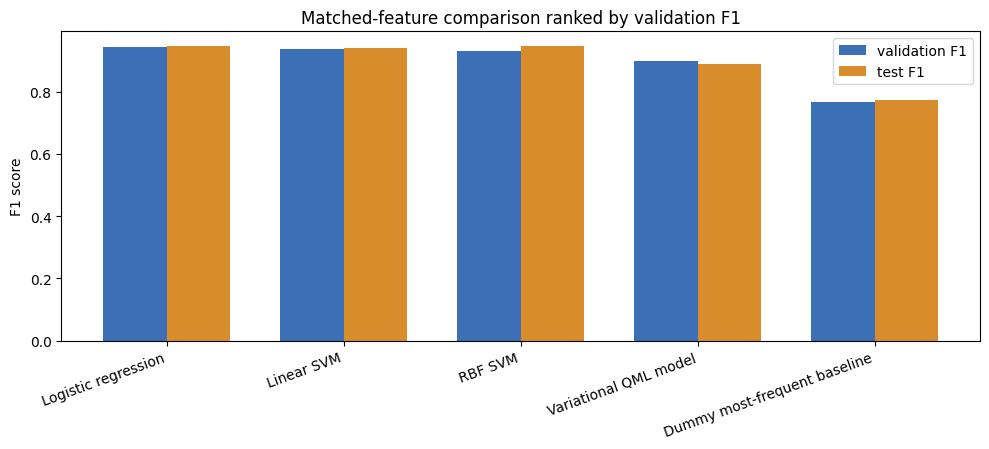


Ordered by validation F1: ['Logistic regression', 'Linear SVM', 'RBF SVM', 'Variational QML model', 'Dummy most-frequent baseline']
Test-F1 gaps relative to Variational QML:
  Logistic regression          -0.0592
  Linear SVM                   -0.0521
  RBF SVM                      -0.0592
  Dummy most-frequent baseline +0.1133


In [2]:
def prepare_matched_breast_cancer(split_seed=11):
    data = load_breast_cancer()
    X = data.data
    y = data.target.astype(int)
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=split_seed, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=split_seed, stratify=y_train_val)
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    pca = PCA(n_components=2, random_state=split_seed).fit(X_train_scaled)
    X_train_pca = pca.transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    angle_scaler = MinMaxScaler(feature_range=(0.0, np.pi)).fit(X_train_pca)
    X_train_angles = angle_scaler.transform(X_train_pca)
    X_val_angles = angle_scaler.transform(X_val_pca)
    X_test_angles = angle_scaler.transform(X_test_pca)
    return {
        'feature_names': list(data.feature_names),
        'X_train': X_train_angles,
        'X_val': X_val_angles,
        'X_test': X_test_angles,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'explained_variance_ratio': pca.explained_variance_ratio_,
    }


def run_matched_models(data_dict, *, quantum_seed=0):
    X_train = data_dict['X_train']
    X_val = data_dict['X_val']
    X_test = data_dict['X_test']
    y_train = data_dict['y_train']
    y_val = data_dict['y_val']
    y_test = data_dict['y_test']
    log_reg = LogisticRegression(max_iter=4000, random_state=quantum_seed)
    rbf_svm = SVC(kernel='rbf', probability=True, random_state=quantum_seed)
    log_reg.fit(X_train, y_train)
    rbf_svm.fit(X_train, y_train)
    quantum_result = train_quantum_classifier(X_train, y_train, X_val, y_val, seed=quantum_seed)
    q_weights = quantum_result['weights']
    rows = []
    rows.append(metric_row('Logistic regression', 'validation', y_val, log_reg.predict(X_val), log_reg.predict_proba(X_val)[:, 1]))
    rows.append(metric_row('RBF SVM', 'validation', y_val, rbf_svm.predict(X_val), rbf_svm.predict_proba(X_val)[:, 1]))
    rows.append(metric_row('Variational QML model', 'validation', y_val, quantum_predict_labels(X_val, q_weights), quantum_probabilities(X_val, q_weights)))
    rows.append(metric_row('Logistic regression', 'test', y_test, log_reg.predict(X_test), log_reg.predict_proba(X_test)[:, 1]))
    rows.append(metric_row('RBF SVM', 'test', y_test, rbf_svm.predict(X_test), rbf_svm.predict_proba(X_test)[:, 1]))
    rows.append(metric_row('Variational QML model', 'test', y_test, quantum_predict_labels(X_test, q_weights), quantum_probabilities(X_test, q_weights)))
    test_predictions = {
        'Logistic regression': log_reg.predict(X_test),
        'RBF SVM': rbf_svm.predict(X_test),
        'Variational QML model': quantum_predict_labels(X_test, q_weights),
    }
    test_confusions = {name: confusion_matrix(y_test, y_pred) for name, y_pred in test_predictions.items()}
    trained = {'log_reg': log_reg, 'rbf_svm': rbf_svm, 'quantum': quantum_result, 'test_confusions': test_confusions}
    return rows, trained

case_data_task1 = prepare_matched_breast_cancer(split_seed=11)
rows_base, _ = run_matched_models(case_data_task1, quantum_seed=3)

X_train = case_data_task1['X_train']
X_val = case_data_task1['X_val']
X_test = case_data_task1['X_test']
y_train = case_data_task1['y_train']
y_val = case_data_task1['y_val']
y_test = case_data_task1['y_test']

dummy = DummyClassifier(strategy='most_frequent')
linear_svm = SVC(kernel='linear', probability=True, random_state=11)
dummy.fit(X_train, y_train)
linear_svm.fit(X_train, y_train)

extra_rows = [
    metric_row('Dummy most-frequent baseline', 'validation', y_val, dummy.predict(X_val), dummy.predict_proba(X_val)[:, 1]),
    metric_row('Linear SVM', 'validation', y_val, linear_svm.predict(X_val), linear_svm.predict_proba(X_val)[:, 1]),
    metric_row('Dummy most-frequent baseline', 'test', y_test, dummy.predict(X_test), dummy.predict_proba(X_test)[:, 1]),
    metric_row('Linear SVM', 'test', y_test, linear_svm.predict(X_test), linear_svm.predict_proba(X_test)[:, 1]),
]

all_rows = rows_base + extra_rows
print_metric_table(all_rows)

by_split = {'validation': {}, 'test': {}}
for row in all_rows:
    by_split[row['split']][row['model']] = row

ordered_models = sorted(by_split['validation'], key=lambda name: by_split['validation'][name]['f1'], reverse=True)
val_f1 = [by_split['validation'][name]['f1'] for name in ordered_models]
test_f1 = [by_split['test'][name]['f1'] for name in ordered_models]

x = np.arange(len(ordered_models))
width = 0.36
plt.figure(figsize=(10.0, 4.6))
plt.bar(x - width / 2, val_f1, width=width, label='validation F1', color='#3b6fb6')
plt.bar(x + width / 2, test_f1, width=width, label='test F1', color='#d98c2b')
plt.xticks(x, ordered_models, rotation=20, ha='right')
plt.ylabel('F1 score')
plt.title('Matched-feature comparison ranked by validation F1')
plt.legend()
plt.tight_layout()
plt.show()

qml_name = 'Variational QML model'
qml_test_f1 = by_split['test'][qml_name]['f1']
gaps = {}
for model_name in ordered_models:
    if model_name != qml_name:
        gaps[model_name] = qml_test_f1 - by_split['test'][model_name]['f1']

print('\nOrdered by validation F1:', ordered_models)
print('Test-F1 gaps relative to Variational QML:')
for model_name, gap in gaps.items():
    print(f'  {model_name:<28} {gap:+.4f}')


The added baselines make the matched comparison more diagnostic. The dummy classifier checks whether the representation is being used at all, while the linear SVM asks whether a simple linear decision rule on that same two-feature representation is already sufficient. Ordering the models by validation $F_1$ and then comparing the corresponding test $F_1$ values forces the analysis to move beyond isolated scalar outputs: it becomes possible to see not only who wins once, but also how large the gaps actually are.

If the variational QML model beats only the dummy baseline, then the result supports at most the claim that the quantum model is using the features better than a trivial majority rule. If it also beats the linear SVM, then it is already clearing a more meaningful matched baseline. If it finishes on top of the full matched table, then the evidence is stronger still, although it would remain a matched-representation claim rather than a broad statement about the original prediction problem. The explicit test-$F_1$ gaps are useful here because they show whether the observed differences are substantial or only marginal.


<a id="task2-solution"></a>

## Task 2 (coding): One complete solution

We now quantify the leakage-induced optimism gap across several split seeds and several values of $k$ under the same label-aware feature-selection mistake.


{'k': 2, 'mean_clean': 0.9221, 'mean_leaked': 0.9418, 'mean_gap': 0.0197, 'max_gap': 0.0343}
{'k': 4, 'mean_clean': 0.9259, 'mean_leaked': 0.9469, 'mean_gap': 0.021, 'max_gap': 0.0557}
{'k': 6, 'mean_clean': 0.9452, 'mean_leaked': 0.9456, 'mean_gap': 0.0004, 'max_gap': 0.0086}
{'k': 8, 'mean_clean': 0.9465, 'mean_leaked': 0.9456, 'mean_gap': -0.0009, 'max_gap': 0.0}

Largest mean optimism gap occurs at k = 4


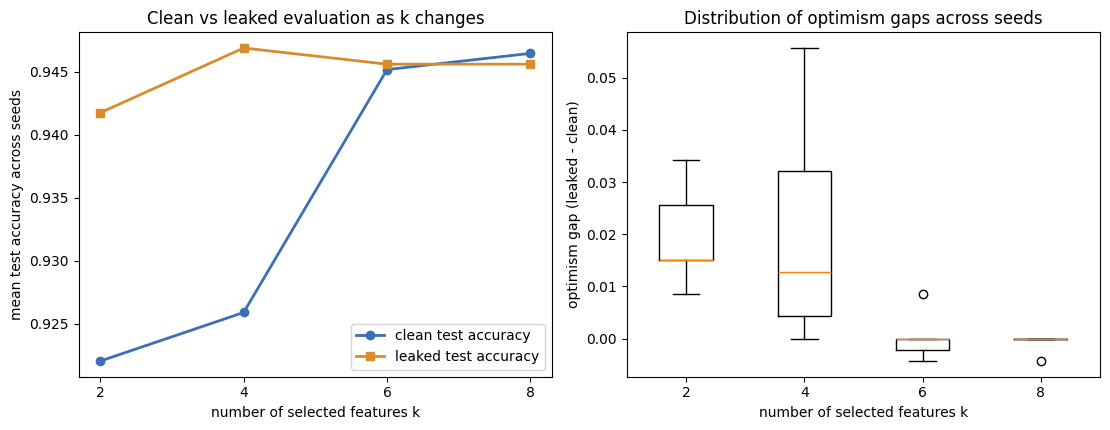

In [3]:
def selector_leakage_study(split_seed=13, k=2, train_fraction=0.18):
    data = load_breast_cancer()
    X = data.data
    y = data.target.astype(int)
    feature_names = np.asarray(data.feature_names)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1.0 - train_fraction, random_state=split_seed, stratify=y)
    clean_selector = SelectKBest(score_func=f_classif, k=k).fit(X_train, y_train)
    X_train_clean = clean_selector.transform(X_train)
    X_test_clean = clean_selector.transform(X_test)
    clean_scaler = StandardScaler().fit(X_train_clean)
    X_train_clean = clean_scaler.transform(X_train_clean)
    X_test_clean = clean_scaler.transform(X_test_clean)
    clean_model = LogisticRegression(max_iter=4000, random_state=split_seed).fit(X_train_clean, y_train)
    clean_acc = float(accuracy_score(y_test, clean_model.predict(X_test_clean)))
    leaked_selector = SelectKBest(score_func=f_classif, k=k).fit(X, y)
    X_train_leaked = leaked_selector.transform(X_train)
    X_test_leaked = leaked_selector.transform(X_test)
    leaked_scaler = StandardScaler().fit(X_train_leaked)
    X_train_leaked = leaked_scaler.transform(X_train_leaked)
    X_test_leaked = leaked_scaler.transform(X_test_leaked)
    leaked_model = LogisticRegression(max_iter=4000, random_state=split_seed).fit(X_train_leaked, y_train)
    leaked_acc = float(accuracy_score(y_test, leaked_model.predict(X_test_leaked)))
    return {
        'split_seed': split_seed,
        'k': k,
        'train_fraction': train_fraction,
        'clean_test_accuracy': clean_acc,
        'leaked_test_accuracy': leaked_acc,
        'optimism_gap': leaked_acc - clean_acc,
        'clean_indices': clean_selector.get_support(indices=True),
        'leaked_indices': leaked_selector.get_support(indices=True),
        'clean_features': list(feature_names[clean_selector.get_support(indices=True)]),
        'leaked_features': list(feature_names[leaked_selector.get_support(indices=True)]),
    }

leakage_seeds = [3, 7, 11, 19, 27]
k_values_task2 = [2, 4, 6, 8]
train_fraction_task2 = 0.18

leakage_rows = []
for k_value in k_values_task2:
    for seed in leakage_seeds:
        leakage_rows.append(selector_leakage_study(split_seed=seed, k=k_value, train_fraction=train_fraction_task2))

for k_value in k_values_task2:
    subset = [row for row in leakage_rows if row['k'] == k_value]
    mean_clean = float(np.mean([row['clean_test_accuracy'] for row in subset]))
    mean_leaked = float(np.mean([row['leaked_test_accuracy'] for row in subset]))
    mean_gap = float(np.mean([row['optimism_gap'] for row in subset]))
    max_gap = float(np.max([row['optimism_gap'] for row in subset]))
    print({'k': k_value, 'mean_clean': round(mean_clean, 4), 'mean_leaked': round(mean_leaked, 4), 'mean_gap': round(mean_gap, 4), 'max_gap': round(max_gap, 4)})

mean_clean_by_k = []
mean_leaked_by_k = []
gap_lists = []
mean_gap_by_k = []
for k_value in k_values_task2:
    subset = [row for row in leakage_rows if row['k'] == k_value]
    clean_vals = [row['clean_test_accuracy'] for row in subset]
    leaked_vals = [row['leaked_test_accuracy'] for row in subset]
    gap_vals = [row['optimism_gap'] for row in subset]
    mean_clean_by_k.append(float(np.mean(clean_vals)))
    mean_leaked_by_k.append(float(np.mean(leaked_vals)))
    gap_lists.append(gap_vals)
    mean_gap_by_k.append(float(np.mean(gap_vals)))

best_k = k_values_task2[int(np.argmax(mean_gap_by_k))]
print('\nLargest mean optimism gap occurs at k =', best_k)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4))
axes[0].plot(k_values_task2, mean_clean_by_k, marker='o', linewidth=2, label='clean test accuracy', color='#3b6fb6')
axes[0].plot(k_values_task2, mean_leaked_by_k, marker='s', linewidth=2, label='leaked test accuracy', color='#d98c2b')
axes[0].set_xlabel('number of selected features k')
axes[0].set_ylabel('mean test accuracy across seeds')
axes[0].set_title('Clean vs leaked evaluation as k changes')
axes[0].set_xticks(k_values_task2)
axes[0].legend()

axes[1].boxplot(gap_lists, tick_labels=k_values_task2)
axes[1].set_xlabel('number of selected features k')
axes[1].set_ylabel('optimism gap (leaked - clean)')
axes[1].set_title('Distribution of optimism gaps across seeds')

fig.tight_layout()
plt.show()


The figure separates two complementary questions. The left panel shows whether the leaked protocol tends to inflate the reported test accuracy relative to the clean protocol as the number of selected features changes. The right panel shows whether that inflation is consistent across seeds or driven only by a few outliers. Together, these panels make the leakage effect easier to read than a single scalar summary.

If the leaked curve stays above the clean curve and the boxplots remain mostly above zero, then leakage is producing a systematic optimism effect rather than a one-off accident. The value of $k$ with the largest mean optimism gap is especially useful because it identifies where the invalid protocol looks most persuasive. But that does not make the protocol any more acceptable: once the selector has seen labels from outside the training split, the reported test performance is no longer an honest estimate of generalization, even if the resulting trend looks smooth or stable.


<a id="task3-solution"></a>

## Task 3 (coding): One complete solution

We now ask a stronger question than “who wins most often?” This solution studies whether the validation ranking is a reliable proxy for the test ranking by tracking rank shifts and validation-to-test $F_1$ gaps across repeated fair splits. This solution reuses `prepare_matched_breast_cancer(...)` and `run_matched_models(...)` from Task 1, and then adds helpers specific to the repeated-run ranking study.


{'seed': 2, 'validation_rank': {'RBF SVM': 1, 'Logistic regression': 2, 'Variational QML model': 3}, 'test_rank': {'Logistic regression': 1, 'RBF SVM': 2, 'Variational QML model': 3}, 'validation_winner': 'RBF SVM', 'test_winner': 'Logistic regression'}
{'seed': 7, 'validation_rank': {'RBF SVM': 1, 'Logistic regression': 2, 'Variational QML model': 3}, 'test_rank': {'Logistic regression': 1, 'RBF SVM': 2, 'Variational QML model': 3}, 'validation_winner': 'RBF SVM', 'test_winner': 'Logistic regression'}
{'seed': 13, 'validation_rank': {'Logistic regression': 1, 'RBF SVM': 2, 'Variational QML model': 3}, 'test_rank': {'RBF SVM': 1, 'Logistic regression': 2, 'Variational QML model': 3}, 'validation_winner': 'Logistic regression', 'test_winner': 'RBF SVM'}
{'seed': 29, 'validation_rank': {'RBF SVM': 1, 'Logistic regression': 2, 'Variational QML model': 3}, 'test_rank': {'RBF SVM': 1, 'Logistic regression': 2, 'Variational QML model': 3}, 'validation_winner': 'RBF SVM', 'test_winner': 'RBF 

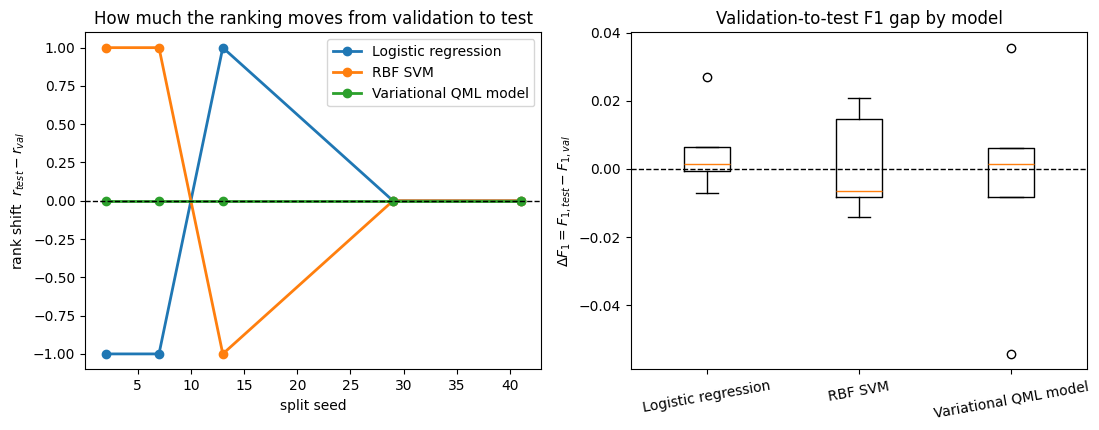

In [4]:
def repeated_matched_study(split_seeds):
    rows = []
    for seed in split_seeds:
        # These helpers were defined in Task 1
        data_dict = prepare_matched_breast_cancer(split_seed=seed)
        metric_rows, _ = run_matched_models(data_dict, quantum_seed=seed)
        for row in metric_rows:
            enriched = row.copy()
            enriched['split_seed'] = seed
            rows.append(enriched)
    return rows


def rank_models(rows_for_one_split):
    ordered = sorted(rows_for_one_split, key=lambda row: row['f1'], reverse=True)
    return {row['model']: rank + 1 for rank, row in enumerate(ordered)}


repeat_seeds_task3 = [2, 7, 13, 29, 41]
study_rows_task3 = repeated_matched_study(repeat_seeds_task3)
models = sorted({row['model'] for row in study_rows_task3})

winner_match_count = 0
rank_shift_by_model = {model: [] for model in models}
delta_f1_by_model = {model: [] for model in models}

for seed in repeat_seeds_task3:
    val_rows = [row for row in study_rows_task3 if row['split_seed'] == seed and row['split'] == 'validation']
    test_rows = [row for row in study_rows_task3 if row['split_seed'] == seed and row['split'] == 'test']

    val_rank = rank_models(val_rows)
    test_rank = rank_models(test_rows)
    val_f1 = {row['model']: row['f1'] for row in val_rows}
    test_f1 = {row['model']: row['f1'] for row in test_rows}

    validation_winner = min(val_rank, key=val_rank.get)
    test_winner = min(test_rank, key=test_rank.get)
    winner_match_count += int(validation_winner == test_winner)

    print({'seed': seed, 'validation_rank': val_rank, 'test_rank': test_rank,
           'validation_winner': validation_winner, 'test_winner': test_winner})

    for model in models:
        rank_shift_by_model[model].append(test_rank[model] - val_rank[model])
        delta_f1_by_model[model].append(test_f1[model] - val_f1[model])

print('\nValidation winner = test winner on', winner_match_count, 'out of', len(repeat_seeds_task3), 'seeds')

mean_abs_rank_shift = {model: float(np.mean(np.abs(rank_shift_by_model[model]))) for model in models}
mean_abs_delta_f1 = {model: float(np.mean(np.abs(delta_f1_by_model[model]))) for model in models}
print('mean absolute rank shift:', mean_abs_rank_shift)
print('mean absolute Delta F1 :', mean_abs_delta_f1)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.4))
for model in models:
    axes[0].plot(repeat_seeds_task3, rank_shift_by_model[model], marker='o', linewidth=2, label=model)
axes[0].axhline(0.0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('split seed')
axes[0].set_ylabel('rank shift  $r_{test} - r_{val}$')
axes[0].set_title('How much the ranking moves from validation to test')
axes[0].legend()

axes[1].boxplot([delta_f1_by_model[model] for model in models], tick_labels=models)
axes[1].axhline(0.0, color='black', linewidth=1, linestyle='--')
axes[1].set_ylabel(r'$\Delta F_1 = F_{1,test} - F_{1,val}$')
axes[1].set_title('Validation-to-test F1 gap by model')
plt.xticks(rotation=10)
fig.tight_layout()
plt.show()


If the validation winner matches the test winner only part of the time, then model selection based on one split is already fragile. The left panel shows that the ranking is not equally stable for all models: in this run the logistic-regression and RBF-SVM lines move by about one rank in opposite directions for several seeds, while the variational QML model stays at rank shift zero across the five splits. So the top two classical models exchange positions depending on the seed, whereas the QML model keeps the same rank even though that rank is not necessarily the winning one.

The right panel shows a different notion of stability. Here the question is not whether the rank changes, but whether the validation $F_1$ is close to the test $F_1$. All three boxplots are centered fairly near zero, which means that validation and test performance are often similar, but they are not identical. The RBF SVM has a slightly more negative center, suggesting that its test $F_1$ tends to fall a bit below its validation $F_1$, while the variational QML model shows a wider spread with noticeable outliers even though its rank stays fixed in the left panel. Together, the two panels show why rank stability and metric-gap stability are related but different: a model can keep the same position across splits and still show non-negligible validation-to-test variation.
